- Exercício: Regressão e Validação de Modelos

| Coluna  | Tipo	| Descrição |
|---------|-------|-----------|
| area_m2 | float | Área do imóvel em m² |
| quartos | int	| Número de quartos (1–4) |
| banheiros | int	| Número de banheiros (1–3) |
| vagas | int	| Vagas de garagem (0–3) |
| andar | int	| Andar do imóvel (0 = térreo) |
| idade_predio | int | Idade do prédio em anos (0–40) |
| bairro | categorical | Bairro (Pinheiros, Moema, Vila Mariana, Lapa, Santana, Tatuapé) |
| aluguel | float | Target — Valor do aluguel em R$ |

- CSV

|   area_m2 | quartos | banheiros | vagas | andar | idade_predio | bairro | aluguel |
|---------  | -------|-----------|-------|-------|--------------|--------|---------|

DATASET: Aluguéis SP
Dimensões: 300 imóveis x 8 colunas

Colunas: ['area_m2', 'quartos', 'banheiros', 'vagas', 'andar', 'idade_predio', 'bairro', 'aluguel']

Primeiras linhas:
   area_m2  quartos  banheiros  vagas  andar  idade_predio     bairro  aluguel
0     89.3        2          2      0     12            22    Tatuapé  3873.75
1    172.9        4          3      0      7            28  Pinheiros  8652.84
2    141.1        2          1      2     17            17       Lapa  4932.75
3    121.8        3          2      2      0            30    Tatuapé  5513.54
4     57.6        3          3      0     14            29    Tatuapé  3265.84

Estatísticas descritivas:
       area_m2  quartos  banheiros   vagas   andar  idade_predio   aluguel
count   300.00   300.00     300.00  300.00  300.00        300.00    300.00
mean    106.80     2.18       1.86    1.27   10.28         20.59   5278.78
std      42.68     0.96       0.79    0.93    6.21         11.64   1696.81
min      35.70     1.00

c:\Users\lucas\IdeaProjects VSCode\ai-algorithms\venv_ia\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


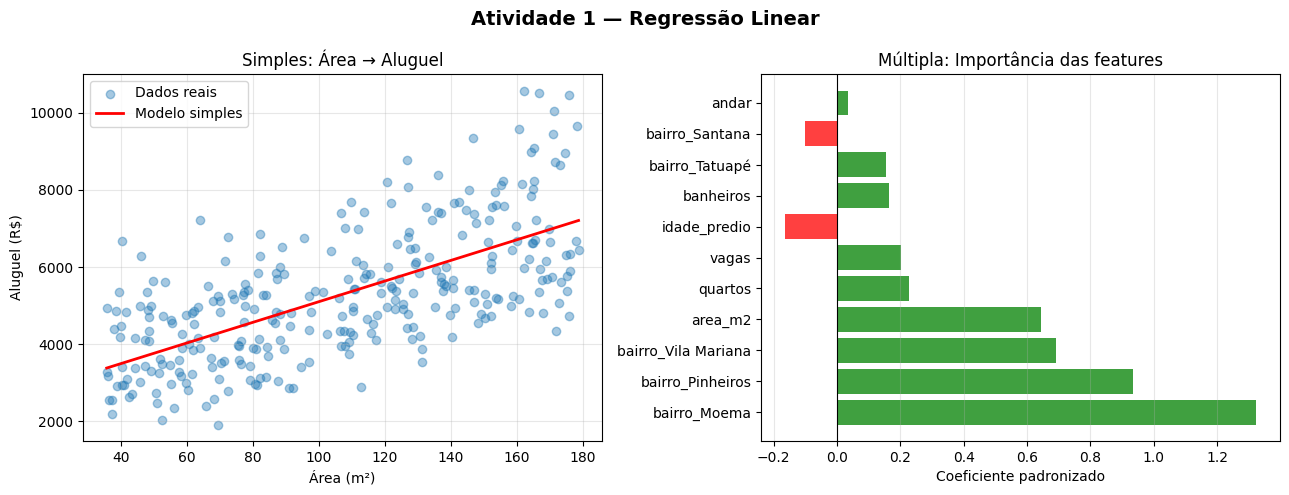


ATIVIDADE 2 — REGULARIZAÇÃO: RIDGE, LASSO E ELASTICNET

  Features após PolynomialFeatures grau 2: 27

[Tarefa 2a] Comparação de modelos regularizados
Modelo                  R²_treino   R²_teste   RMSE_teste  Features_ativas
------------------------------------------------------------------------
  LinearRegression         0.6986     0.4571 R$     1,139               27
  Ridge (α=1)              0.6985     0.4603 R$     1,136               27
  Ridge (α=10)             0.6971     0.4825 R$     1,113               27
  Lasso (α=1)              0.6985     0.4595 R$     1,137               26
  Lasso (α=10)             0.6969     0.4728 R$     1,123               20
  ElasticNet               0.6262     0.5230 R$     1,068               27

[Tarefa 2d] Alpha ótimo via CV:
  RidgeCV → α = 24.2013  | R²_teste = 0.5040
  LassoCV → α = 66.6138  | R²_teste = 0.5083
  LassoCV → features ativas = 14 / 27


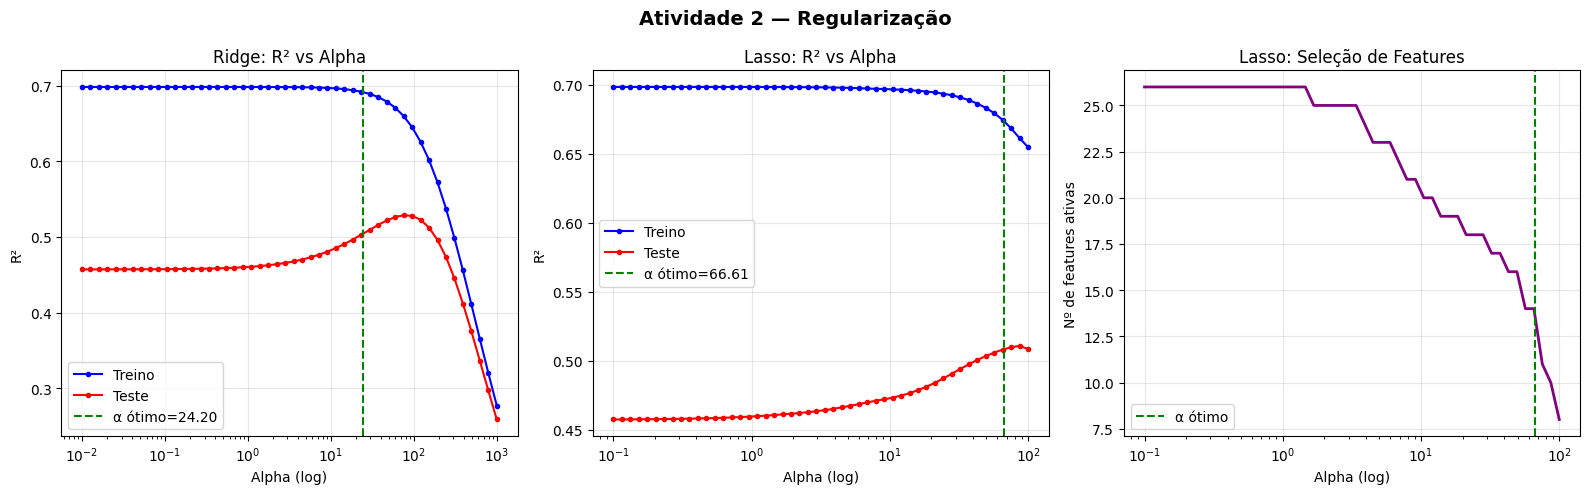


ATIVIDADE 3 — PIPELINE COMPLETO COM FE + CV + RESÍDUOS

[Tarefa 3a] Features após engineering: 12 entradas
  Novas features: area_por_quarto, total_comodos, log_area, andar_alto, predio_novo

[Tarefa 3b] Validação Cruzada (5-fold) com Feature Engineering:
Modelo                   R² médio   R² std   RMSE médio   MAE médio
-----------------------------------------------------------------
  LinearRegression         0.9212   0.0187 R$      466  R$     374
  Ridge (CV)               0.9211   0.0188 R$      467  R$     373
  Lasso (CV)               0.9214   0.0187 R$      466  R$     374

  → Melhor modelo: Lasso (CV) (R² médio = 0.9214)

[Tarefa 3c] Análise de Resíduos — Lasso (CV)
  Média dos resíduos (treino): -0.00  (deve ser ~0)
  Desvio padrão (treino):      437.70

  Teste de Normalidade (Shapiro-Wilk):
    Estatística: 0.9929  |  p-valor: 0.3061
    ✅ Resíduos normalmente distribuídos

  Teste de Homocedasticidade (Levene):
    Estatística: 10.7136  |  p-valor: 0.0012
    ⚠️  Hete

C:\Users\lucas\AppData\Local\Temp\ipykernel_24492\1812441912.py:442: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\lucas\IdeaProjects VSCode\ai-algorithms\venv_ia\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


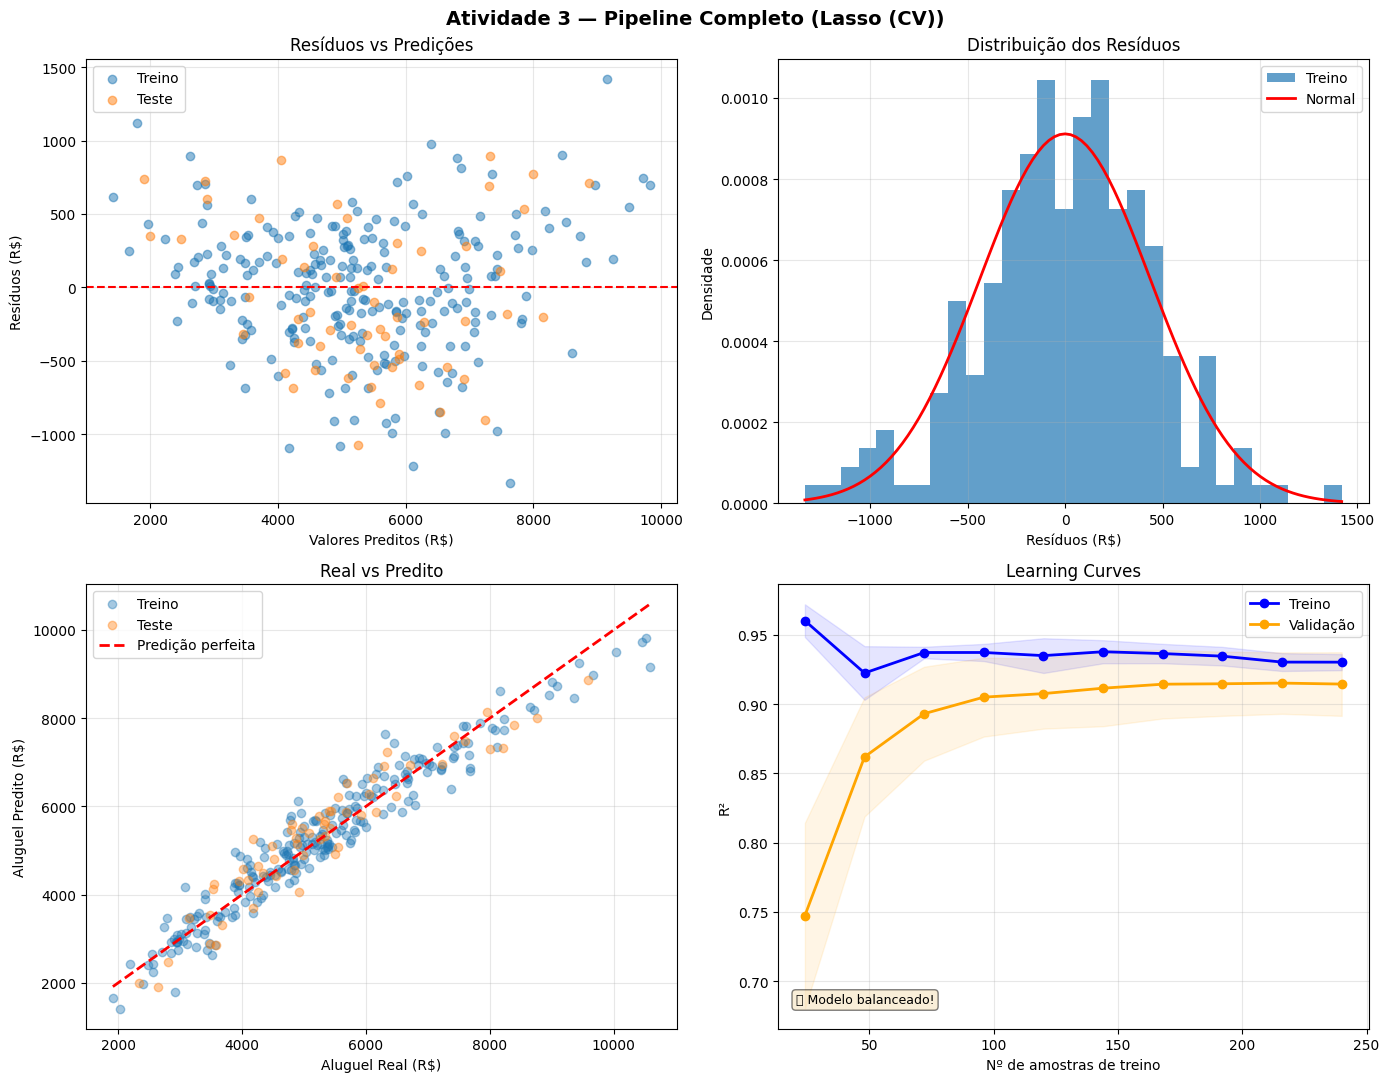


✅ Solução completa das 3 atividades da Aula 06 finalizada!


In [47]:
# GO0637-AtividadesAula06-Solucao
# ═══════════════════════════════════════════════════════════════════
# SOLUÇÃO COMPLETA — 3 ATIVIDADES DA AULA 06
# Regressão, Regularização e Pipeline Completo
# Dataset: alugueis_sp.csv
# ═══════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_validate, KFold, learning_curve
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy import stats

# ───────────────────────────────────────────────────────────────────
# CARREGAMENTO DO DATASET
# ───────────────────────────────────────────────────────────────────

import os

# Suporta execução de qualquer diretório
#BASE_DIR = os.path.dirname((os.path.abspath(__file__))
#CSV_PATH = os.path.join(BASE_DIR, 'ia_12_alugueis_sp.csv')
#df = pd.read_csv(CSV_PATH)

df = pd.read_csv('ia_12_alugueis_sp.csv')

print("=" * 65)
print("DATASET: Aluguéis SP")
print("=" * 65)
print(f"Dimensões: {df.shape[0]} imóveis x {df.shape[1]} colunas")
print(f"\nColunas: {list(df.columns)}")
print(f"\nPrimeiras linhas:")
print(df.head())
print(f"\nEstatísticas descritivas:")
print(df.describe().round(2))

# ═══════════════════════════════════════════════════════════════════
# ATIVIDADE 1 — REGRESSÃO LINEAR SIMPLES E MÚLTIPLA
# ═══════════════════════════════════════════════════════════════════

print("\n" + "=" * 65)
print("ATIVIDADE 1 — REGRESSÃO LINEAR SIMPLES E MÚLTIPLA")
print("=" * 65)

# ── Tarefa 1a: Regressão Linear SIMPLES (área → aluguel) ──────────

X_simples = df[['area_m2']]
y = df['aluguel']

X_train_s, X_test_s, y_train, y_test = train_test_split(
    X_simples, y, test_size=0.2, random_state=42
)

modelo_simples = LinearRegression()
modelo_simples.fit(X_train_s, y_train)
y_pred_s = modelo_simples.predict(X_test_s)

print("\n[Tarefa 1a] Regressão Linear SIMPLES — área → aluguel")
print(f"  Intercepto (β₀): R$ {modelo_simples.intercept_:,.2f}")
print(f"  Coeficiente (β₁): R$ {modelo_simples.coef_[0]:,.2f} por m²")
print(f"  Fórmula: aluguel = {modelo_simples.intercept_:,.0f} + {modelo_simples.coef_[0]:,.2f} × área")
print(f"\n  Métricas no conjunto de teste:")
print(f"    RMSE: R$ {np.sqrt(mean_squared_error(y_test, y_pred_s)):,.2f}")
print(f"    MAE:  R$ {mean_absolute_error(y_test, y_pred_s):,.2f}")
print(f"    R²:   {r2_score(y_test, y_pred_s):.4f}")

# ── Tarefa 1b: Regressão Linear MÚLTIPLA ─────────────────────────

# Preparar features numéricas + One-Hot para bairro
num_features = ['area_m2', 'quartos', 'banheiros', 'vagas', 'andar', 'idade_predio']
cat_features = ['bairro']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_features)
])

X_multi = df[num_features + cat_features]
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y, test_size=0.2, random_state=42
)

pipeline_multi = Pipeline([
    ('prep', preprocessor),
    ('model', LinearRegression())
])

pipeline_multi.fit(X_train_m, y_train_m)
y_pred_m = pipeline_multi.predict(X_test_m)

print("\n[Tarefa 1b] Regressão Linear MÚLTIPLA — todas as features")
print(f"\n  Métricas no conjunto de teste:")
print(f"    RMSE: R$ {np.sqrt(mean_squared_error(y_test_m, y_pred_m)):,.2f}")
print(f"    MAE:  R$ {mean_absolute_error(y_test_m, y_pred_m):,.2f}")
print(f"    R²:   {r2_score(y_test_m, y_pred_m):.4f}")

# ── Tarefa 1c: Coeficientes padronizados (importância) ───────────

scaler_y = StandardScaler()
X_prep = preprocessor.fit_transform(X_multi)
y_std = scaler_y.fit_transform(y.values.reshape(-1, 1)).ravel()

lr_std = LinearRegression().fit(X_prep, y_std)

feat_names_num = num_features
feat_names_cat = pipeline_multi.named_steps['prep'] \
    .named_transformers_['cat'].get_feature_names_out(cat_features).tolist()
all_feat_names = feat_names_num + feat_names_cat

coef_df = pd.DataFrame({
    'feature': all_feat_names,
    'coef_padronizado': lr_std.coef_
}).sort_values('coef_padronizado', key=abs, ascending=False)

print("\n[Tarefa 1c] Coeficientes Padronizados (importância relativa):")
print(coef_df.to_string(index=False))

# ── Tarefa 1d: Visualização ───────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Atividade 1 — Regressão Linear', fontsize=14, fontweight='bold')

# Scatter área vs aluguel com linha de regressão
axes[0].scatter(df['area_m2'], df['aluguel'], alpha=0.4, label='Dados reais')
x_line = np.linspace(df['area_m2'].min(), df['area_m2'].max(), 100).reshape(-1, 1)
axes[0].plot(x_line, modelo_simples.predict(x_line), color='red', lw=2, label='Modelo simples')
axes[0].set_xlabel('Área (m²)')
axes[0].set_ylabel('Aluguel (R$)')
axes[0].set_title('Simples: Área → Aluguel')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Importância das features
colors = ['green' if c >= 0 else 'red' for c in coef_df['coef_padronizado']]
axes[1].barh(coef_df['feature'], coef_df['coef_padronizado'], color=colors, alpha=0.75)
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_xlabel('Coeficiente padronizado')
axes[1].set_title('Múltipla: Importância das features')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════
# ATIVIDADE 2 — REGULARIZAÇÃO: RIDGE, LASSO E ELASTICNET
# ═══════════════════════════════════════════════════════════════════

print("\n" + "=" * 65)
print("ATIVIDADE 2 — REGULARIZAÇÃO: RIDGE, LASSO E ELASTICNET")
print("=" * 65)

# Preparar dados (com features polinomiais grau 2 para criar multicolinearidade)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_num_scaled = StandardScaler().fit_transform(df[num_features])
X_poly = poly.fit_transform(X_num_scaled)
print(f"\n  Features após PolynomialFeatures grau 2: {X_poly.shape[1]}")

X_tr, X_te, y_tr, y_te = train_test_split(X_poly, y, test_size=0.2, random_state=42)

# ── Tarefa 2a: Comparar modelos ──────────────────────────────────

modelos = {
    'LinearRegression': LinearRegression(),
    'Ridge (α=1)':      Ridge(alpha=1.0),
    'Ridge (α=10)':     Ridge(alpha=10.0),
    'Lasso (α=1)':      Lasso(alpha=1.0, max_iter=5000),
    'Lasso (α=10)':     Lasso(alpha=10.0, max_iter=5000),
    'ElasticNet':       ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=5000),
}

print(f"\n[Tarefa 2a] Comparação de modelos regularizados")
print(f"{'Modelo':<22} {'R²_treino':>10} {'R²_teste':>10} {'RMSE_teste':>12} {'Features_ativas':>16}")
print("-" * 72)

resultados = {}
for nome, modelo in modelos.items():
    modelo.fit(X_tr, y_tr)
    r2_tr = r2_score(y_tr, modelo.predict(X_tr))
    r2_te = r2_score(y_te, modelo.predict(X_te))
    rmse_te = np.sqrt(mean_squared_error(y_te, modelo.predict(X_te)))
    n_ativas = np.sum(np.abs(modelo.coef_) > 1e-6) if hasattr(modelo, 'coef_') else '-'
    resultados[nome] = (r2_tr, r2_te, rmse_te, n_ativas)
    print(f"  {nome:<20} {r2_tr:>10.4f} {r2_te:>10.4f} R${rmse_te:>10,.0f} {str(n_ativas):>16}")

# ── Tarefa 2b: Curva de regularização Ridge ──────────────────────

alphas = np.logspace(-2, 3, 50)
r2_treino_ridge, r2_teste_ridge = [], []
for a in alphas:
    m = Ridge(alpha=a).fit(X_tr, y_tr)
    r2_treino_ridge.append(r2_score(y_tr, m.predict(X_tr)))
    r2_teste_ridge.append(r2_score(y_te, m.predict(X_te)))

# ── Tarefa 2c: Curva de regularização Lasso ─────────────────────

alphas_l = np.logspace(-1, 2, 50)
r2_treino_lasso, r2_teste_lasso, n_feat_lasso = [], [], []
for a in alphas_l:
    m = Lasso(alpha=a, max_iter=5000).fit(X_tr, y_tr)
    r2_treino_lasso.append(r2_score(y_tr, m.predict(X_tr)))
    r2_teste_lasso.append(r2_score(y_te, m.predict(X_te)))
    n_feat_lasso.append(np.sum(np.abs(m.coef_) > 1e-6))

# ── Tarefa 2d: RidgeCV e LassoCV — alpha ideal ──────────────────

ridge_cv = RidgeCV(alphas=np.logspace(-2, 3, 100), cv=5).fit(X_tr, y_tr)
lasso_cv = LassoCV(cv=5, max_iter=5000, random_state=42).fit(X_tr, y_tr)
print(f"\n[Tarefa 2d] Alpha ótimo via CV:")
print(f"  RidgeCV → α = {ridge_cv.alpha_:.4f}  | R²_teste = {r2_score(y_te, ridge_cv.predict(X_te)):.4f}")
print(f"  LassoCV → α = {lasso_cv.alpha_:.4f}  | R²_teste = {r2_score(y_te, lasso_cv.predict(X_te)):.4f}")
print(f"  LassoCV → features ativas = {np.sum(np.abs(lasso_cv.coef_) > 1e-6)} / {X_poly.shape[1]}")

# ── Tarefa 2e: Visualização ──────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Atividade 2 — Regularização', fontsize=14, fontweight='bold')

# Curva Ridge
axes[0].plot(alphas, r2_treino_ridge, 'b-o', ms=3, label='Treino')
axes[0].plot(alphas, r2_teste_ridge, 'r-o', ms=3, label='Teste')
axes[0].axvline(ridge_cv.alpha_, color='green', ls='--', label=f'α ótimo={ridge_cv.alpha_:.2f}')
axes[0].set_xscale('log')
axes[0].set_xlabel('Alpha (log)')
axes[0].set_ylabel('R²')
axes[0].set_title('Ridge: R² vs Alpha')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Curva Lasso
axes[1].plot(alphas_l, r2_treino_lasso, 'b-o', ms=3, label='Treino')
axes[1].plot(alphas_l, r2_teste_lasso, 'r-o', ms=3, label='Teste')
axes[1].axvline(lasso_cv.alpha_, color='green', ls='--', label=f'α ótimo={lasso_cv.alpha_:.2f}')
axes[1].set_xscale('log')
axes[1].set_xlabel('Alpha (log)')
axes[1].set_ylabel('R²')
axes[1].set_title('Lasso: R² vs Alpha')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Lasso: features ativas vs alpha
axes[2].plot(alphas_l, n_feat_lasso, 'purple', lw=2)
axes[2].axvline(lasso_cv.alpha_, color='green', ls='--', label=f'α ótimo')
axes[2].set_xscale('log')
axes[2].set_xlabel('Alpha (log)')
axes[2].set_ylabel('Nº de features ativas')
axes[2].set_title('Lasso: Seleção de Features')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════
# ATIVIDADE 3 — PIPELINE COMPLETO: FE + CV + ANÁLISE DE RESÍDUOS
# ═══════════════════════════════════════════════════════════════════

print("\n" + "=" * 65)
print("ATIVIDADE 3 — PIPELINE COMPLETO COM FE + CV + RESÍDUOS")
print("=" * 65)

# ── Tarefa 3a: Feature Engineering ──────────────────────────────

df2 = df.copy()
df2['area_por_quarto'] = df2['area_m2'] / df2['quartos']
df2['total_comodos']   = df2['quartos'] + df2['banheiros']
df2['log_area']        = np.log1p(df2['area_m2'])
df2['andar_alto']      = (df2['andar'] >= 10).astype(int)
df2['predio_novo']     = (df2['idade_predio'] <= 5).astype(int)

num_fe = ['area_m2', 'quartos', 'banheiros', 'vagas', 'andar', 'idade_predio',
          'area_por_quarto', 'total_comodos', 'log_area', 'andar_alto', 'predio_novo']
cat_fe = ['bairro']

print(f"\n[Tarefa 3a] Features após engineering: {len(num_fe) + len(cat_fe)} entradas")
print(f"  Novas features: area_por_quarto, total_comodos, log_area, andar_alto, predio_novo")

prep_fe = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_fe),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_fe)
])

X_fe = df2[num_fe + cat_fe]
y_fe = df2['aluguel']

# ── Tarefa 3b: Comparar modelos com validação cruzada ────────────

kf = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['r2', 'neg_root_mean_squared_error', 'neg_mean_absolute_error']

modelos_cv = {
    'LinearRegression': Pipeline([('prep', prep_fe), ('model', LinearRegression())]),
    'Ridge (CV)':       Pipeline([('prep', prep_fe), ('model', RidgeCV(alphas=np.logspace(-2,3,50), cv=5))]),
    'Lasso (CV)':       Pipeline([('prep', prep_fe), ('model', LassoCV(cv=5, max_iter=5000, random_state=42))]),
}

print(f"\n[Tarefa 3b] Validação Cruzada (5-fold) com Feature Engineering:")
print(f"{'Modelo':<22} {'R² médio':>10} {'R² std':>8} {'RMSE médio':>12} {'MAE médio':>11}")
print("-" * 65)

melhor_modelo_nome = None
melhor_r2 = -np.inf

for nome, pipe in modelos_cv.items():
    cv_res = cross_validate(pipe, X_fe, y_fe, cv=kf, scoring=scoring)
    r2_m    = cv_res['test_r2'].mean()
    r2_s    = cv_res['test_r2'].std()
    rmse_m  = -cv_res['test_neg_root_mean_squared_error'].mean()
    mae_m   = -cv_res['test_neg_mean_absolute_error'].mean()
    print(f"  {nome:<20} {r2_m:>10.4f} {r2_s:>8.4f} R${rmse_m:>9,.0f}  R${mae_m:>8,.0f}")
    if r2_m > melhor_r2:
        melhor_r2 = r2_m
        melhor_modelo_nome = nome

print(f"\n  → Melhor modelo: {melhor_modelo_nome} (R² médio = {melhor_r2:.4f})")

# ── Tarefa 3c: Análise de Resíduos do melhor modelo ─────────────

X_tr2, X_te2, y_tr2, y_te2 = train_test_split(X_fe, y_fe, test_size=0.2, random_state=42)
melhor_pipe = modelos_cv[melhor_modelo_nome]
melhor_pipe.fit(X_tr2, y_tr2)

y_pred_tr2 = melhor_pipe.predict(X_tr2)
y_pred_te2 = melhor_pipe.predict(X_te2)
res_treino  = y_tr2.values - y_pred_tr2
res_teste   = y_te2.values - y_pred_te2

print(f"\n[Tarefa 3c] Análise de Resíduos — {melhor_modelo_nome}")
print(f"  Média dos resíduos (treino): {res_treino.mean():,.2f}  (deve ser ~0)")
print(f"  Desvio padrão (treino):      {res_treino.std():,.2f}")

stat_sw, p_sw = stats.shapiro(res_treino[:5000])
print(f"\n  Teste de Normalidade (Shapiro-Wilk):")
print(f"    Estatística: {stat_sw:.4f}  |  p-valor: {p_sw:.4f}")
print(f"    {'✅ Resíduos normalmente distribuídos' if p_sw > 0.05 else '⚠️  Resíduos não normais (transformar alvo?)'}")

mid = len(y_pred_tr2) // 2
idx_s = np.argsort(y_pred_tr2)
stat_lv, p_lv = stats.levene(res_treino[idx_s[:mid]], res_treino[idx_s[mid:]])
print(f"\n  Teste de Homocedasticidade (Levene):")
print(f"    Estatística: {stat_lv:.4f}  |  p-valor: {p_lv:.4f}")
print(f"    {'✅ Variância constante (homocedasticidade)' if p_lv > 0.05 else '⚠️  Heterocedasticidade detectada'}")

# ── Tarefa 3d: Learning Curves ───────────────────────────────────

train_sizes, tr_scores, val_scores = learning_curve(
    melhor_pipe, X_fe, y_fe,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5, scoring='r2', n_jobs=-1
)

tr_mean  = tr_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)
tr_std   = tr_scores.std(axis=1)
val_std  = val_scores.std(axis=1)

gap_final = tr_mean[-1] - val_mean[-1]
if gap_final > 0.15:
    diag = "⚠️ OVERFITTING — reduzir complexidade ou regularizar"
elif val_mean[-1] < 0.6:
    diag = "⚠️ UNDERFITTING — aumentar complexidade"
elif val_mean[-1] - val_mean[-2] > 0.01:
    diag = "📈 Mais dados podem ajudar — curva não estabilizou"
else:
    diag = "✅ Modelo balanceado!"

print(f"\n[Tarefa 3d] Learning Curve:")
print(f"  Score treino (final):     {tr_mean[-1]:.4f} ± {tr_std[-1]:.4f}")
print(f"  Score validação (final):  {val_mean[-1]:.4f} ± {val_std[-1]:.4f}")
print(f"  Gap treino - val:         {gap_final:.4f}")
print(f"  Diagnóstico: {diag}")

# ── Tarefa 3e: Predição de exemplo ──────────────────────────────

exemplo = pd.DataFrame([{
    'area_m2': 90, 'quartos': 2, 'banheiros': 2, 'vagas': 1,
    'andar': 8, 'idade_predio': 10, 'bairro': 'Vila Mariana',
    'area_por_quarto': 45, 'total_comodos': 4,
    'log_area': np.log1p(90), 'andar_alto': 0, 'predio_novo': 0
}])
pred = melhor_pipe.predict(exemplo)[0]
print(f"\n[Tarefa 3e] Predição de exemplo:")
print(f"  Imóvel: 90m², 2 quartos, 2 banheiros, 1 vaga, 8º andar, 10 anos, Vila Mariana")
print(f"  Aluguel estimado: R$ {pred:,.2f}")

# ── Visualização final (4 plots) ─────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle(f'Atividade 3 — Pipeline Completo ({melhor_modelo_nome})',
             fontsize=14, fontweight='bold')

# 1. Resíduos vs Preditos
axes[0, 0].scatter(y_pred_tr2, res_treino, alpha=0.5, label='Treino')
axes[0, 0].scatter(y_pred_te2, res_teste,  alpha=0.5, label='Teste')
axes[0, 0].axhline(0, color='red', ls='--', lw=1.5)
axes[0, 0].set_xlabel('Valores Preditos (R$)')
axes[0, 0].set_ylabel('Resíduos (R$)')
axes[0, 0].set_title('Resíduos vs Predições')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Histograma dos resíduos
axes[0, 1].hist(res_treino, bins=30, alpha=0.7, density=True, label='Treino')
mu, sd = res_treino.mean(), res_treino.std()
x_n = np.linspace(res_treino.min(), res_treino.max(), 100)
axes[0, 1].plot(x_n, stats.norm.pdf(x_n, mu, sd), 'r-', lw=2, label='Normal')
axes[0, 1].set_xlabel('Resíduos (R$)')
axes[0, 1].set_ylabel('Densidade')
axes[0, 1].set_title('Distribuição dos Resíduos')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Real vs Predito
lims = [min(y_tr2.min(), y_te2.min()), max(y_tr2.max(), y_te2.max())]
axes[1, 0].scatter(y_tr2, y_pred_tr2, alpha=0.4, label='Treino')
axes[1, 0].scatter(y_te2, y_pred_te2, alpha=0.4, label='Teste')
axes[1, 0].plot(lims, lims, 'r--', lw=2, label='Predição perfeita')
axes[1, 0].set_xlabel('Aluguel Real (R$)')
axes[1, 0].set_ylabel('Aluguel Predito (R$)')
axes[1, 0].set_title('Real vs Predito')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Learning Curves
axes[1, 1].fill_between(train_sizes, tr_mean - tr_std,  tr_mean + tr_std,  alpha=0.1, color='blue')
axes[1, 1].fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='orange')
axes[1, 1].plot(train_sizes, tr_mean,  'o-', color='blue',   label='Treino', lw=2)
axes[1, 1].plot(train_sizes, val_mean, 'o-', color='orange', label='Validação', lw=2)
axes[1, 1].set_xlabel('Nº de amostras de treino')
axes[1, 1].set_ylabel('R²')
axes[1, 1].set_title('Learning Curves')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].text(0.03, 0.05, diag, transform=axes[1, 1].transAxes, fontsize=9,
                verticalalignment='bottom',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("\n" + "=" * 65)
print("✅ Solução completa das 3 atividades da Aula 06 finalizada!")
print("=" * 65)